In [1]:

# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\moham\anaconda3\envs\luke_py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_us['job_posted_month_no'] = df_da_us['job_posted_date'].dt.month

df_da_us_explode = df_da_us.explode('job_skills')

In [15]:
df_da_us_pivot = df_da_us_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

In [17]:
df_da_us_pivot.loc['Total'] = df_da_us_pivot.sum()
df_da_us_pivot = df_da_us_pivot[df_da_us_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_us_pivot = df_da_us_pivot.drop('Total')

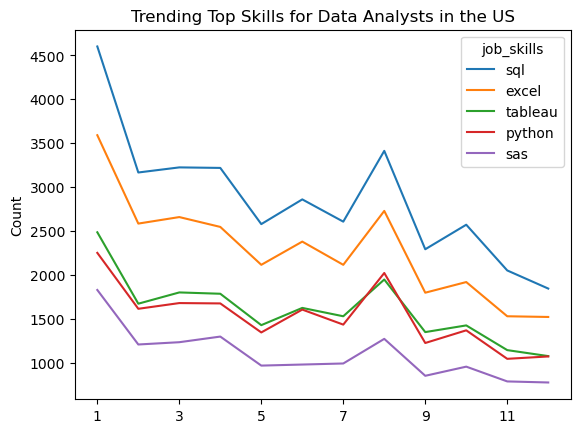

In [18]:
df_da_us_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [19]:
DA_totals = df_da_us.groupby('job_posted_month_no').size()

df_da_us_per = df_da_us_pivot.iloc[:12].div(DA_totals/100, axis=0)

df_da_us_per = df_da_us_per.reset_index()
df_da_us_per['job_posted_month'] = df_da_us_per['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_us_per = df_da_us_per.set_index('job_posted_month')
df_da_us_per = df_da_us_per.drop(columns='job_posted_month_no')


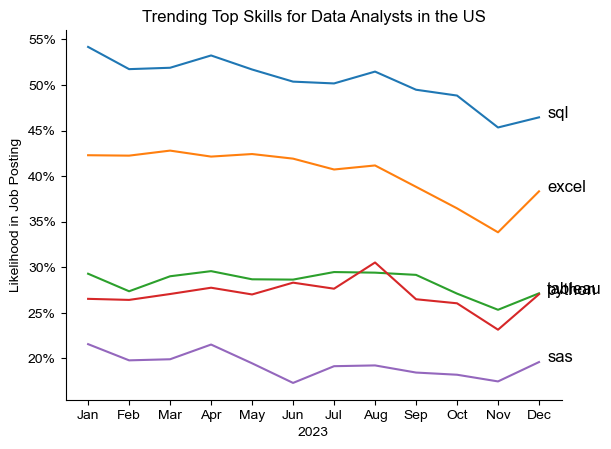

In [20]:
from matplotlib.ticker import PercentFormatter

df_plot = df_da_us_per.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()